### "Шапка" с названием проекта

В этой ячейке вы найдете оглавление и ключевые этапы работы, которые помогут вам ориентироваться в процессе выполнения проекта. Проект разделен на пять основных этапов, четыре из которых (этапы 2, 3, 4 и 5) вам предлагается выполнить в этом Jupyter Notebook:

- Подготовка среды MLflow - Первый шаг, подготовка и запуск сервисов MLflow, был выполнен вне ноутбука и оформлен в виде shell скрипта. Это основа для работы с экспериментами и логирования результатов ваших моделей.

- Этап 2 - Исследовательский Анализ Данных (EDA): На этом этапе вы проведете тщательный анализ данных, чтобы лучше понять их структуру и особенности.

- Этап 3 - Генерация Признаков и Обучение Модели: После анализа данных вы сгенерируете новые признаки и обучите модель, используя эти признаки.

- Этап 4 - Отбор Признаков и Обучение Модели: На этом шаге вы отберете наиболее значимые признаки и снова обучите модель для улучшения ее качества.

- Этап 5 - Подбор Гиперпараметров и Обучение Финальной Версии Модели: Финальный этап проекта посвящен оптимизации гиперпараметров для достижения максимального качества модели.

Для удобства навигации и организации работы, пожалуйста, следуйте оглавлению и рекомендациям, описанным в каждом этапе.

> ### Важно: Переобучение моделей
> На каждом этапе проекта, где требуется переобучение модели, важно не просто выполнить эту процедуру, но и тщательно проверить качество модели на соответствующих выборках. Это включает в себя анализ метрик качества, визуализацию результатов, сравнение с предыдущими моделями и, при необходимости, корректировку.

> ### Важно: Разделение выборок
> Перед началом выполнения вашего проекта важно правильно подготовить данные, разделив их на подвыборки. Это позволит оценить производительность модели более объективно и управлять риском переобучения. В зависимости от ваших целей и доступных данных, вы можете использовать различные стратегии разделения:

1. Разделение на train/val/test: Это классический подход, где данные делятся на три части. Обучающая выборка (train) используется для первичного обучения моделей, валидационная (val) - для настройки гиперпараметров и выбора лучшей модели, а тестовая (test) - для финальной оценки производительности модели. Такой подход идеален, если у вас достаточно данных, чтобы разделить их и каждая из выборок была репрезентативна.

2. Разделение на train/test с кросс-валидацией на train: Если данных недостаточно для трех подвыборок, можно ограничиться разделением на обучающую и тестовую выборки. В этом случае кросс-валидация на обучающей выборке поможет оценить стабильность модели и подобрать гиперпараметры.

Определение способа разделения данных: Выбор метода разбиения данных на подвыборки — train, validation и test — должен быть обоснован особенностями вашего набора данных и задачами проекта. Возможные методы разделения, включая различные стратегии и правила, подробно описаны в [документации scikit-learn по разбиению данных](https://scikit-learn.org/stable/auto_examples/model_selection/plot_cv_indices.html#sphx-glr-auto-examples-model-selection-plot-cv-indices-py). Вы можете следовать этим примерам или разработать собственный метод, исходя из специфики ваших данных.

Ваша задача - выбрать подходящий метод разделения данных исходя из объема и специфики ваших данных. Помните, что финальные метрики качества модели мы будем оценивать на тестовой выборке. Промежуточные результаты после каждого этапа проекта (например, после настройки гиперпараметров) следует оценивать на валидационной выборке, если таковая имеется. Это поможет вам корректно настроить модель перед финальной оценкой её производительности.

In [1]:
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
from sklearn.model_selection import train_test_split
import os
import mlflow

load_dotenv('../.env')

os.environ["MLFLOW_S3_ENDPOINT_URL"] = "https://storage.yandexcloud.net"
os.environ["AWS_ACCESS_KEY_ID"] = os.getenv("AWS_ACCESS_KEY_ID") 
os.environ["AWS_SECRET_ACCESS_KEY"] = os.getenv("AWS_SECRET_ACCESS_KEY") 

mlflow.set_tracking_uri("http://127.0.0.1:5000")

host = os.environ.get('DB_DESTINATION_HOST')
port = os.environ.get('DB_DESTINATION_PORT')
db = os.environ.get('DB_DESTINATION_NAME')
username = os.environ.get('DB_DESTINATION_USER')
password = os.environ.get('DB_DESTINATION_PASSWORD')

engine = create_engine(f'postgresql://{username}:{password}@{host}:{port}/{db}', connect_args={'sslmode':'require'})

query = "SELECT * FROM flats_prepared"
df = pd.read_sql(query, engine)

X = df.drop(columns=['price', 'id'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

#### Этап 2: Исследовательский Анализ Данных (EDA)
На этом этапе ваша задача - провести тщательный исследовательский анализ данных (EDA), чтобы глубже понять особенности и связи в предоставленном наборе данных. В процессе EDA вы должны обратить внимание на три ключевых аспекта, о которых мы говорили в теме 3 курса. Очень важно, чтобы все результаты вашего исследования, включая визуализации, статистический анализ и предварительные выводы, были аккуратно залогированы в MLflow.

Для более организованного исследования предлагаем следующие рекомендуемые шаги:
- Понимание данных: Первоначально ознакомьтесь с данными, изучите типы данных, проверьте наличие пропущенных значений.
- Визуализация данных: Используйте графики и диаграммы для визуализации распределений признаков и возможных взаимосвязей между ними.
- Статистический анализ: Примените статистические методы для изучения центральных тенденций, разброса и корреляций между признаками.
- Предварительные выводы: На основе проведённого анализа сформулируйте предварительные выводы о данных, которые помогут в дальнейшем этапе моделирования.

Помните, что EDA - это итеративный процесс, в котором вы можете возвращаться к предыдущим шагам для дополнительного анализа, если это будет необходимо. Все находки и выводы должны быть чётко зафиксированы и легко доступны для команды проекта.


In [ ]:
# 2.2. Общий обзор датасета

In [2]:
print(df.info())
print("\nПропущенные значения:")
print(df.isnull().sum())
print(f"\nДубликаты: {df.duplicated().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103493 entries, 0 to 103492
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 103493 non-null  int64  
 1   building_id        103493 non-null  int64  
 2   floor              103493 non-null  int64  
 3   kitchen_area       103493 non-null  float64
 4   living_area        103493 non-null  float64
 5   rooms              103493 non-null  int64  
 6   is_apartment       103493 non-null  bool   
 7   studio             103493 non-null  bool   
 8   total_area         103493 non-null  float64
 9   build_year         103493 non-null  int64  
 10  building_type_int  103493 non-null  int64  
 11  latitude           103493 non-null  float64
 12  longitude          103493 non-null  float64
 13  ceiling_height     103493 non-null  float64
 14  flats_count        103493 non-null  int64  
 15  floors_total       103493 non-null  int64  
 16  ha

In [ ]:
# 2.3 Анализ признаков для модели

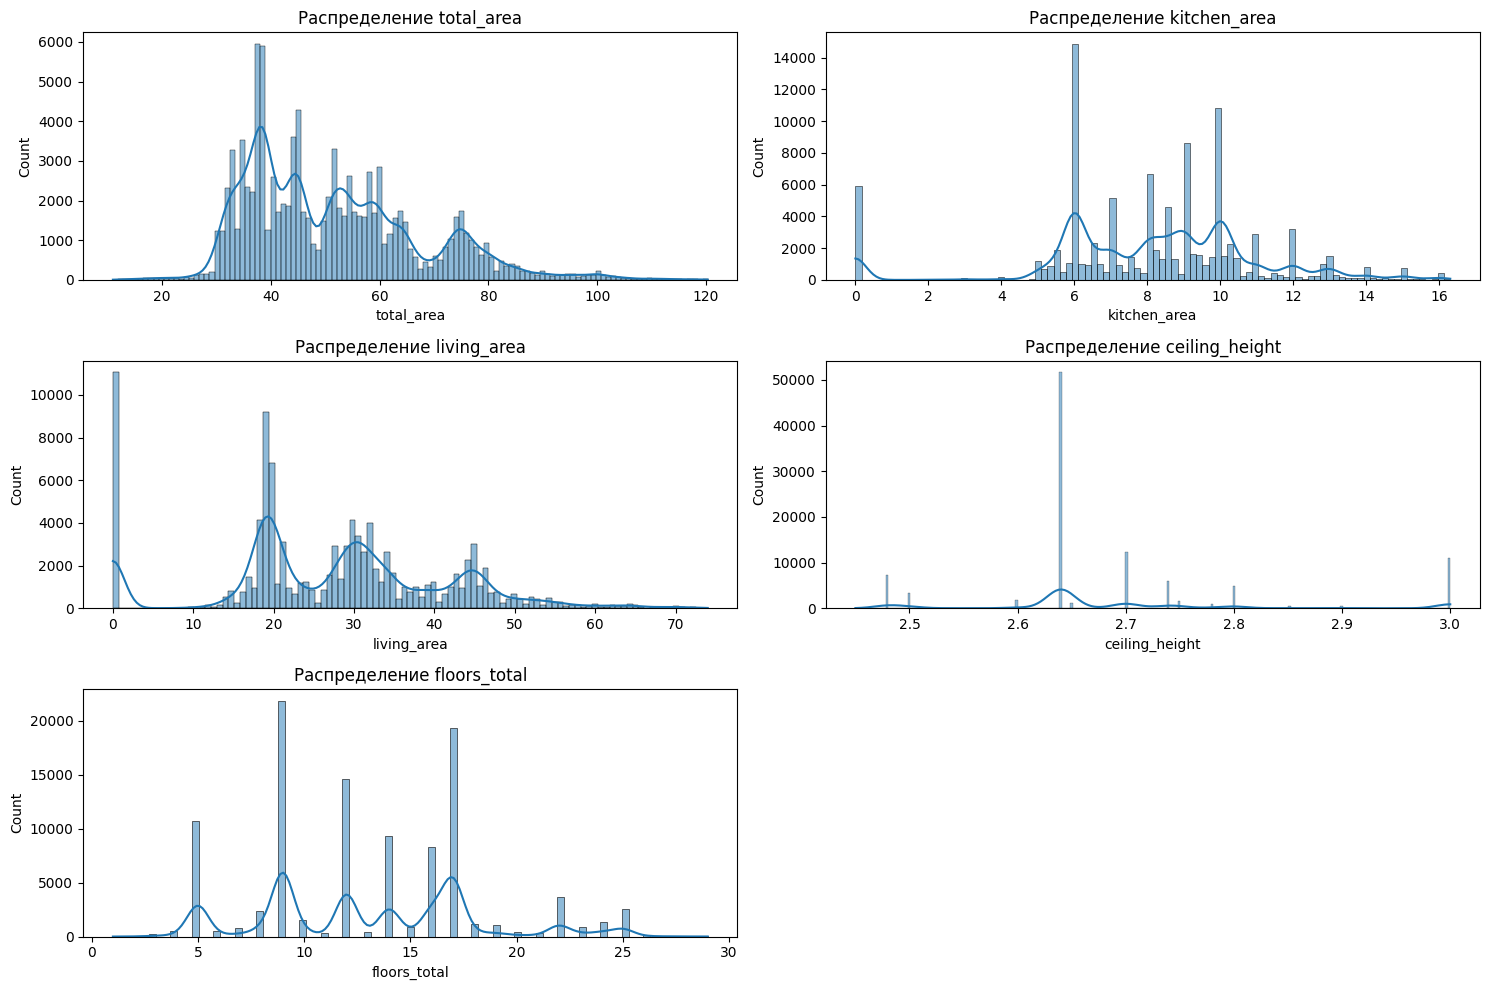

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

cols_to_plot = ['total_area', 'kitchen_area', 'living_area', 'ceiling_height', 'floors_total']

plt.figure(figsize=(15, 10))
for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(3, 2, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Распределение {col}')

plt.tight_layout()
plt.savefig("features_distribution.png")
plt.show()

In [ ]:
# 2.4 Анализ целевой переменной

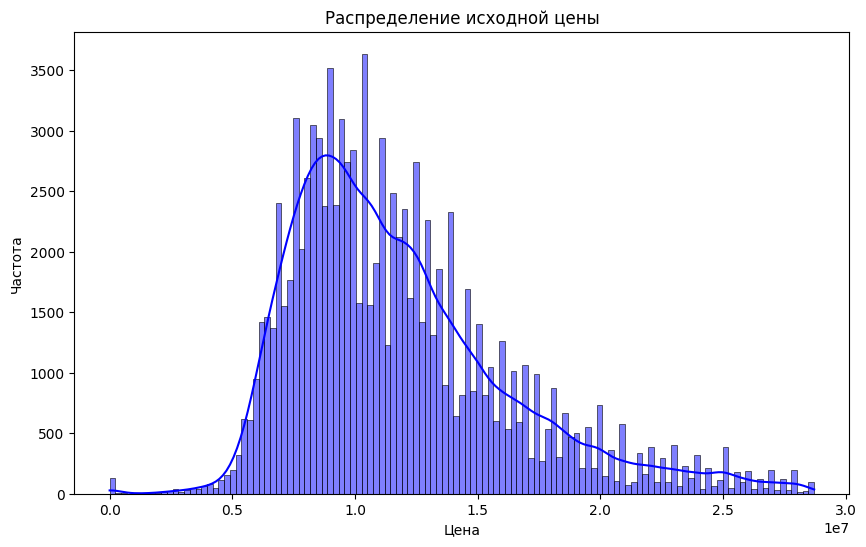

In [4]:
plt.figure(figsize=(10, 6))

sns.histplot(df['price'], kde=True, color='blue')
plt.title('Распределение исходной цены')
plt.xlabel('Цена')
plt.ylabel('Частота')

plt.savefig("target_distribution.png")
plt.show()

In [ ]:
# 2.4 Анализ целевой переменной в зависимости от различных признаков

/tmp/ipykernel_2998/4108024204.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='rooms', y='price', palette='viridis')


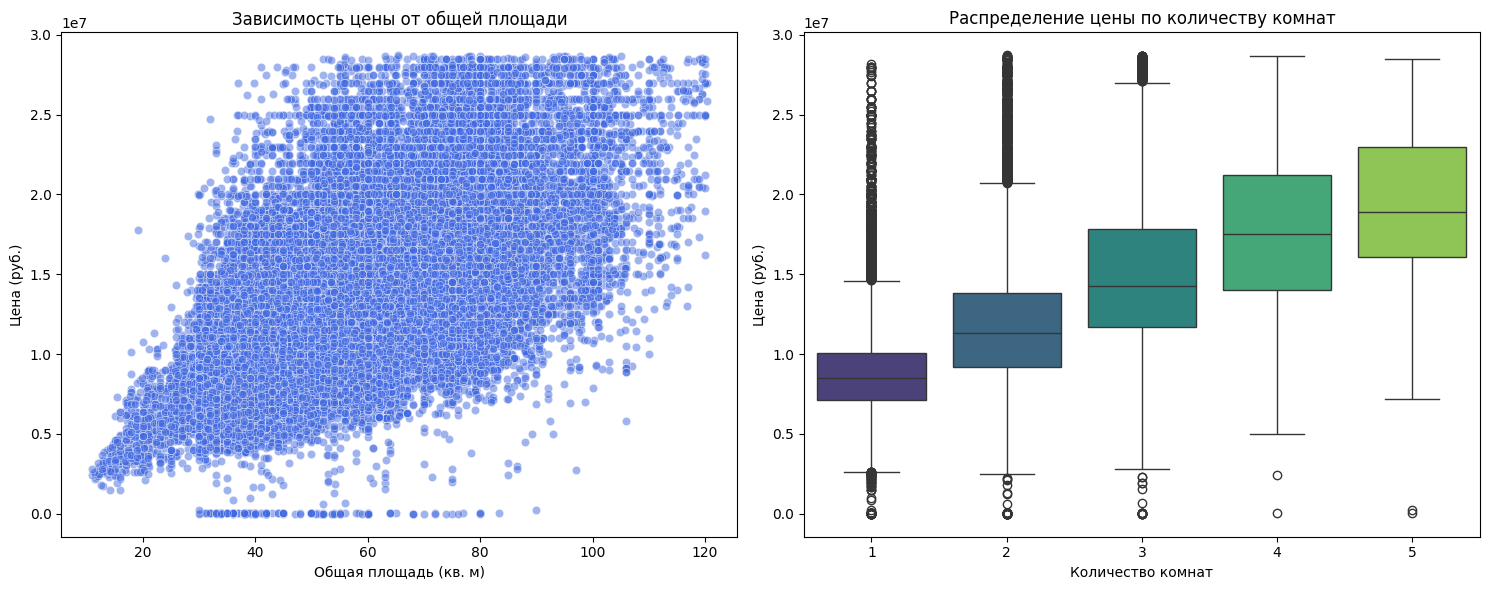

In [5]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='total_area', y='price', alpha=0.5, color='royalblue')
plt.title('Зависимость цены от общей площади')
plt.xlabel('Общая площадь (кв. м)')
plt.ylabel('Цена (руб.)')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='rooms', y='price', palette='viridis')
plt.title('Распределение цены по количеству комнат')
plt.xlabel('Количество комнат')
plt.ylabel('Цена (руб.)')

plt.tight_layout()
plt.savefig("price_dependencies.png")
plt.show()

In [ ]:
# 2.5 Выводы после EDA

In [ ]:
# Распределение цены имеет выраженный длинный хвост вправо. 
# Большинство объектов недвижимости сосредоточено в диапазоне от 5 до 15 млн рублей. встречаются лоты стоимостью до 30 млн рублей.

# На графике «Зависимость цены от общей площади» видна четкая положительная корреляция: чем больше площадь, тем выше цена. 
# Однако разброс увеличивается вместе с ростом площади, что говорит о влиянии других факторов (район, ремонт) на дорогих объектах.

# Самая высокая корреляция с ценой наблюдается у total_area и living_area.

# Высокая плотность данных в определенных диапазонах (этажность, потолки) подтверждает, 
# что добавление признаков вроде «возраст дома» или «тип застройки» поможет модели лучше разделять эти сегменты

In [ ]:
# 2.6 логирование артефактов в MLflow

In [2]:
if mlflow.active_run():
    mlflow.end_run()

mlflow.set_experiment("EDA_Research")

with mlflow.start_run(run_name="EDA_Visualizations_Final"):
    mlflow.log_param("dataset_rows", df.shape[0])
    mlflow.log_param("dataset_cols", df.shape[1])
    mlflow.log_param("target_variable", "price")
    
    mlflow.log_artifact("features_distribution.png")
    mlflow.log_artifact("target_distribution.png")
    mlflow.log_artifact("price_dependencies.png")
    
    import os
    if os.path.exists("correlation_matrix.png"):
        mlflow.log_artifact("correlation_matrix.png")
    
    eda_summary = """
    Выводы после EDA:
    - Целевая переменная 'price' имеет правосторонний скос, основные цены: 5-15 млн руб.
    - Выявлена сильная линейная зависимость цены от 'total_area'.
    - Количество комнат ('rooms') напрямую влияет на медианную стоимость объекта.
    - Распределения признаков указывают на преобладание типовой застройки (пики в ceiling_height и floors_total).
    """
    with open("eda_summary.txt", "w") as f:
        f.write(eda_summary)
    mlflow.log_artifact("eda_summary.txt")

2026/05/09 17:07:25 INFO mlflow.tracking.fluent: Experiment with name 'EDA_Research' does not exist. Creating a new experiment.


#### Этап 3: Генерация Признаков и Обучение Новой Версии Модели
После тщательного исследовательского анализа данных (EDA), вы, скорее всего, сформировали несколько гипотез относительно новых признаков, которые могут улучшить качество вашей модели. На этом этапе, мы предлагаем вам приступить к генерации новых признаков и последующему обучению модели, используя два подхода:

Ручная генерация признаков: Используйте ваше понимание данных и результаты EDA для создания новых признаков.
Автоматическая генерация признаков: Воспользуйтесь библиотеками для автоматической генерации признаков, чтобы облегчить и ускорить этот процесс.
Важно: Для признаков, созданных вручную, рекомендуется использовать объекты sklearn, такие как Pipeline и ColumnTransformer. Это позволит автоматизировать процесс преобразования данных и облегчить поддержку вашего проекта.

После генерации новых признаков, наступает время обучить новую версию вашей модели, используя эти признаки. Не забудьте залогировать все результаты, включая новые признаки, параметры модели и метрики качества, в MLflow для удобства отслеживания изменений и результатов.

Рекомендуемые шаги:

- Определение и генерация новых признаков на основе ваших гипотез.
- Использование библиотек для автоматической генерации признаков, если это применимо.
- Интеграция новых признаков в вашу модель с помощью Pipeline или ColumnTransformer для ручно созданных признаков.
- Обучение новой версии модели с использованием всех доступных признаков.
- Логирование результатов в MLflow для документирования и анализа эффективности новых признаков и модели.

Этот этап проекта критически важен для повышения точности и эффективности вашей модели. Тщательная работа на этом этапе может существенно повлиять на итоговое качество моделирования.


In [ ]:
# 3.1 ручная генерация признаков

In [2]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np

class ManualFeatureGenerator(BaseEstimator, TransformerMixin):
    def __init__(self):
        # Координаты центра Санкт-Петербурга 
        self.spb_center_lat = 59.934280
        self.spb_center_lon = 30.335098
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_copy = X.copy()
        

        X_copy['dist_to_center'] = np.sqrt(
            (X_copy['latitude'] - self.spb_center_lat)**2 + 
            (X_copy['longitude'] - self.spb_center_lon)**2
        ) * 111
        X_copy['house_age'] = 2026 - X_copy['build_year']
        X_copy['living_to_total_ratio'] = X_copy['living_area'] / X_copy['total_area']
        X_copy['kitchen_to_total_ratio'] = X_copy['kitchen_area'] / X_copy['total_area']
        X_copy['area_per_room'] = X_copy['total_area'] / (X_copy['rooms'] + 1)
        X_copy = X_copy.replace([np.inf, -np.inf], np.nan).fillna(0)
        
        return X_copy

In [ ]:
# 3.2 оборачивание всех преобразований в объекты sklearn

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X_train = X_train.astype({col: 'int' for col in X_train.select_dtypes('bool').columns})
X_test = X_test.astype({col: 'int' for col in X_test.select_dtypes('bool').columns})

prep_pipeline = Pipeline([
    ('manual_features', ManualFeatureGenerator()),
    ('scaler', StandardScaler()) 
])

X_train_prepped_array = prep_pipeline.fit_transform(X_train)
X_test_prepped_array = prep_pipeline.transform(X_test)

temp_df = prep_pipeline.named_steps['manual_features'].transform(X_train.iloc[:1])
feature_names = temp_df.columns

X_train_prepped = pd.DataFrame(X_train_prepped_array, columns=feature_names)
X_test_prepped = pd.DataFrame(X_test_prepped_array, columns=feature_names)

print(f"Форма данных после подготовки: {X_train_prepped.shape}")

Форма данных после подготовки: (82794, 21)


In [ ]:
# 3.3 автоматическая генерация признаков

In [4]:
from autofeat import AutoFeatRegressor
import numpy as np

X_train_prepped = X_train_prepped.astype('float32')

af = AutoFeatRegressor(verbose=1, feateng_steps=1, featsel_runs=0)

X_train_auto = af.fit_transform(X_train_prepped, y_train)
X_test_auto = af.transform(X_test_prepped)

train_medians = X_train_auto.median()

X_train_auto = X_train_auto.replace([np.inf, -np.inf], np.nan).fillna(train_medians)
X_test_auto = X_test_auto.replace([np.inf, -np.inf], np.nan).fillna(train_medians)

X_train_auto.columns = [str(col) for col in X_train_auto.columns]
X_test_auto.columns = [str(col) for col in X_test_auto.columns]

print(f"Количество признаков после AutoFeat: {X_train_auto.shape[1]}")

2026-05-10 12:48:04,781 INFO: [AutoFeat] The 1 step feature engineering process could generate up to 147 features.
2026-05-10 12:48:04,782 INFO: [AutoFeat] With 82794 data points this new feature matrix would use about 0.05 gb of space.
2026-05-10 12:48:04,785 INFO: [feateng] Step 1: transformation of original features


2026-05-10 12:48:07,910 INFO: [feateng] Generated 88 transformed features from 21 original features - done.
2026-05-10 12:48:07,950 INFO: [feateng] Generated altogether 88 new features in 1 steps
2026-05-10 12:48:07,951 INFO: [feateng] Removing correlated features, as well as additions at the highest level
2026-05-10 12:48:08,094 INFO: [feateng] Generated a total of 88 additional features
2026-05-10 12:48:08,106 WARNING: [AutoFeat] Not performing feature selection.
2026-05-10 12:48:08,107 INFO: [AutoFeat] Computing 81 new features.


2026-05-10 12:48:16,537 INFO: [AutoFeat]    81/   81 new features ...done.
2026-05-10 12:48:16,580 INFO: [AutoFeat] Final dataframe with 102 feature columns (81 new).
2026-05-10 12:48:16,581 INFO: [AutoFeat] Training final regression model.


2026-05-10 12:48:18,061 INFO: [AutoFeat] Trained model: largest coefficients:
2026-05-10 12:48:18,062 INFO: 15108624.292498343
2026-05-10 12:48:18,063 INFO: 2819226.832021 * total_area
2026-05-10 12:48:18,064 INFO: -1002568.284554 * latitude**2
2026-05-10 12:48:18,065 INFO: -914292.697715 * Abs(latitude)
2026-05-10 12:48:18,065 INFO: -836224.336489 * Abs(dist_to_center)
2026-05-10 12:48:18,066 INFO: -826345.002659 * Abs(longitude)
2026-05-10 12:48:18,067 INFO: -384829.493732 * dist_to_center
2026-05-10 12:48:18,068 INFO: -277936.582897 * house_age
2026-05-10 12:48:18,069 INFO: 244114.203678 * ceiling_height
2026-05-10 12:48:18,069 INFO: -217681.573958 * longitude**2
2026-05-10 12:48:18,070 INFO: 200956.706751 * latitude
2026-05-10 12:48:18,071 INFO: -180279.037244 * dist_to_center**3
2026-05-10 12:48:18,072 INFO: 141843.772345 * floors_total
2026-05-10 12:48:18,073 INFO: 127633.633077 * exp(latitude)
2026-05-10 12:48:18,073 INFO: -118422.509221 * floor**2
2026-05-10 12:48:18,074 INFO: 

Количество признаков после AutoFeat: 102


In [ ]:
# 3.4 обучение новой версии модели

In [5]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error

model_v2 = CatBoostRegressor(iterations=1000, depth=6, learning_rate=0.1, verbose=100, random_seed=42)
model_v2.fit(X_train_auto, y_train)
preds = model_v2.predict(X_test_auto)
mae = mean_absolute_error(y_test, preds)

print(f"MAE после генерации признаков: {mae:,.2f}")

0:	learn: 4266620.6909113	total: 115ms	remaining: 1m 54s
100:	learn: 2430071.7247595	total: 4.17s	remaining: 37.1s
200:	learn: 2367973.5029890	total: 7.74s	remaining: 30.8s
300:	learn: 2323636.3596225	total: 11.4s	remaining: 26.4s
400:	learn: 2284873.1392850	total: 15.1s	remaining: 22.5s
500:	learn: 2251862.7956605	total: 18.7s	remaining: 18.7s
600:	learn: 2221324.2534655	total: 22.4s	remaining: 14.9s
700:	learn: 2193836.5834531	total: 26.1s	remaining: 11.1s
800:	learn: 2167530.2824921	total: 29.8s	remaining: 7.4s
900:	learn: 2141997.7471048	total: 33.5s	remaining: 3.68s
999:	learn: 2119010.9069323	total: 37.1s	remaining: 0us
MAE после генерации признаков: 1,809,707.20


In [ ]:
# 3.5 логирование артефактов в MLflow

In [6]:
if mlflow.active_run():
    mlflow.end_run()

mlflow.set_experiment("Feature_Engineering_Stage")

with mlflow.start_run(run_name="AutoFeat_Plus_Manual"):
    mlflow.log_param("total_features", X_train_auto.shape[1])
    mlflow.log_metric("mae", mae)
    
    mlflow.sklearn.log_model(
        sk_model=model_v2,
        artifact_path="model",
        registered_model_name="CatBoost_Sank-Peterburg_Model"
    )
    
    with open("features_list.txt", "w") as f:
        f.write("\n".join(X_train_auto.columns.tolist()))
    mlflow.log_artifact("features_list.txt")

2026-05-10 12:49:41,995 INFO: Found credentials in environment variables.
Registered model 'CatBoost_Sank-Peterburg_Model' already exists. Creating a new version of this model...
2026/05/10 12:49:42 INFO mlflow.tracking._model_registry.client: Waiting up to 300 seconds for model version to finish creation. Model name: CatBoost_Sank-Peterburg_Model, version 2
Created version '2' of model 'CatBoost_Sank-Peterburg_Model'.


#### Этап 4: Отбор Признаков и Обучение Новой Версии Модели
Создание новых признаков — это лишь часть работы. Следующий важный шаг — это убедиться в том, что каждый из этих признаков действительно вносит положительный вклад в качество модели. Некоторые признаки могут оказывать отрицательное влияние на модель, поэтому их следует исключить из анализа.

На этом этапе, мы рекомендуем вам применить различные методы отбора признаков для того, чтобы определить и удалить те признаки, которые не улучшают качество вашей модели. Цель этого этапа — максимизировать производительность модели, удалив избыточные или неинформативные признаки.

После тщательного отбора признаков, пора обучить новую версию вашей модели, уже без негативно влияющих на неё признаков. Важно залогировать результаты этого этапа, включая измененный набор признаков, параметры модели и полученные метрики качества, в MLflow для последующего анализа и сравнения.

Рекомендуемые шаги:

- Применение методов отбора признаков для идентификации и исключения признаков, ухудшающих качество модели.
- Анализ влияния каждого признака на модель, чтобы понять, какие из них наиболее ценные.
- Обучение новой версии модели без негативно влияющих признаков.
- Логирование всех изменений и результатов в MLflow, включая конечный набор признаков, параметры модели и метрики качества.

Этот этап не только поможет улучшить качество вашей модели, но и даст глубокое понимание о важности и влиянии отдельных признаков на результаты моделирования.


In [ ]:
# 4.1 Отбор признаков при помощи метода номер 1

In [7]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

sfs_forward = SFS(lr, 
                  k_features=(10, 15), 
                  forward=True, 
                  floating=False, 
                  scoring='neg_mean_absolute_error',
                  cv=3,
                  n_jobs=-1)

X_train_auto = X_train_auto.replace([np.inf, -np.inf], np.nan).fillna(0)
sfs_forward = sfs_forward.fit(X_train_auto.iloc[:5000], y_train.iloc[:5000])

selected_fwd = list(sfs_forward.k_feature_names_)
print(f"Признаки, отобранные Forward Selection: {selected_fwd}")

Признаки, отобранные Forward Selection: ['floor', 'kitchen_area', 'total_area', 'build_year', 'longitude', 'ceiling_height', 'dist_to_center', 'Abs(latitude)', 'latitude**2', 'latitude**3', 'Abs(longitude)', 'longitude**2', 'Abs(dist_to_center)', 'dist_to_center**2', 'dist_to_center**3']


In [ ]:
# 4.2 Отбор признаков при помощи метода номер 2

In [8]:
sfs_backward = SFS(lr, 
                   k_features=10, 
                   forward=False, 
                   floating=False, 
                   scoring='neg_mean_absolute_error',
                   cv=3,
                   n_jobs=-1)

sfs_backward = sfs_backward.fit(X_train_auto[selected_fwd], y_train)

selected_bwd = list(sfs_backward.k_feature_names_)
print(f"Признаки, отобранные Backward Selection: {selected_bwd}")

Признаки, отобранные Backward Selection: ['kitchen_area', 'total_area', 'build_year', 'longitude', 'ceiling_height', 'dist_to_center', 'Abs(latitude)', 'Abs(longitude)', 'Abs(dist_to_center)', 'dist_to_center**3']


In [ ]:
# 4.3 Анализ отобранных признаков при помощи двух методов и формирование финального списка с признаками для модели

In [9]:
final_features_list = selected_bwd

for i, feat in enumerate(final_features_list, 1):
    print(f"{i}. {feat}")

1. kitchen_area
2. total_area
3. build_year
4. longitude
5. ceiling_height
6. dist_to_center
7. Abs(latitude)
8. Abs(longitude)
9. Abs(dist_to_center)
10. dist_to_center**3


In [ ]:
# 4.4 Обучение новой версии модели

In [10]:
model_v3 = CatBoostRegressor(iterations=1000, depth=6, learning_rate=0.1, verbose=100, random_seed=42)
model_v3.fit(X_train_auto[final_features_list], y_train)

preds = model_v3.predict(X_test_auto[final_features_list])
mae_v3 = mean_absolute_error(y_test, preds)

print(f"MAE на отобранных признаках: {mae_v3:,.2f}")

0:	learn: 4273849.1453525	total: 16.8ms	remaining: 16.7s
100:	learn: 2488321.7563338	total: 1.85s	remaining: 16.5s
200:	learn: 2427487.0685630	total: 3.24s	remaining: 12.9s
300:	learn: 2389711.6360687	total: 4.26s	remaining: 9.9s
400:	learn: 2361039.0450811	total: 5.31s	remaining: 7.94s
500:	learn: 2337526.5449763	total: 6.69s	remaining: 6.66s
600:	learn: 2316588.3965015	total: 8.01s	remaining: 5.32s
700:	learn: 2296975.9494704	total: 9.03s	remaining: 3.85s
800:	learn: 2279907.0569137	total: 10s	remaining: 2.49s
900:	learn: 2263190.1309638	total: 11s	remaining: 1.21s
999:	learn: 2247877.9130824	total: 12s	remaining: 0us
MAE на отобранных признаках: 1,846,251.41


In [ ]:
# 4.5 Логирование всех артефактов в MLflow

2026/05/10 12:51:07 INFO mlflow.tracking.fluent: Experiment with name 'Feature_Selection_Stage' does not exist. Creating a new experiment.
Registered model 'CatBoost_Sank-Peterburg_Model' already exists. Creating a new version of this model...
2026/05/10 12:51:09 INFO mlflow.tracking._model_registry.client: Waiting up to 300 seconds for model version to finish creation. Model name: CatBoost_Sank-Peterburg_Model, version 3
Created version '3' of model 'CatBoost_Sank-Peterburg_Model'.


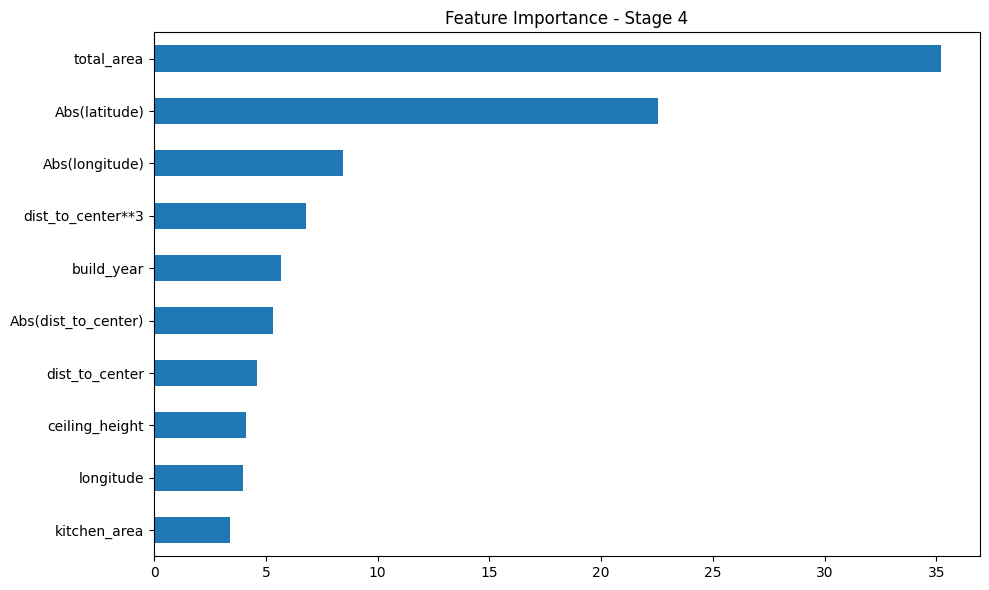

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

if mlflow.active_run():
    mlflow.end_run()

mlflow.set_experiment("Feature_Selection_Stage")

with mlflow.start_run(run_name="Selection_Optimization"):
    mlflow.log_params({"method_1": "Forward SFS", "method_2": "Backward SFS", "n_features": len(final_features_list)})
    mlflow.log_metric("mae", mae_v3)
    
    plt.figure(figsize=(10, 6))
    fi = pd.Series(model_v3.get_feature_importance(), index=final_features_list).sort_values()
    fi.plot(kind='barh')
    plt.title("Feature Importance - Stage 4")
    plt.tight_layout()
    plt.savefig("stage4_feature_importance.png")
    
    mlflow.log_artifact("stage4_feature_importance.png")
    
    mlflow.sklearn.log_model(
        sk_model=model_v3,
        artifact_path="model",
        registered_model_name="CatBoost_Sank-Peterburg_Model"
    )

### Этап 5 - подбор гиперпараметров и обучение новой версии модели
После того как мы уделили значительное внимание качеству модели через создание и отбор признаков, пришло время для финального штриха — подбора гиперпараметров. Этот этап является ключевым в финальной части проекта второго спринта, где ваша задача — оптимизировать гиперпараметры модели для достижения наилучшего качества.

Рекомендуется подобрать гиперпараметры как минимум двумя различными методами (например, с использованием Grid Search и Random Search), чтобы вы могли сравнить результаты и выбрать наиболее эффективный набор гиперпараметров для вашей модели. После определения оптимальных гиперпараметров, наступает время обучить финальную версию модели, используя ваши новые признаки.

Рекомендуемые шаги:

- Выбор методов для подбора гиперпараметров: Определитесь с методами, которые вы будете использовать для подбора гиперпараметров (например, Grid Search, Random Search, Bayesian Optimization).
- Подбор гиперпараметров: Примените выбранные методы для нахождения оптимальных значений гиперпараметров вашей модели.
- Сравнение результатов: Анализируйте и сравнивайте результаты, полученные различными методами, для определения наилучшего набора гиперпараметров.
- Обучение финальной модели: Используя выбранные гиперпараметры, обучите финальную версию вашей модели на новых признаках.
- Документирование процесса и результатов: Залогируйте все шаги и результаты в MLflow, включая сравнение методов подбора гиперпараметров и характеристики финальной модели.

Этот этап позволит вам максимально улучшить качество вашей модели перед финальной оценкой, предоставив полное понимание важности и влияния гиперпараметров на производительность модели.

In [ ]:
# 5.1 Подбор гиперпарметров при мощи метода номер 1

In [26]:
import optuna
from optuna.integration.mlflow import MLflowCallback
import optuna.visualization as vis

def objective(trial):
    params = {
        "iterations": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-2, 10.0, log=True),
        "random_seed": 42,
        "verbose": False
    }
    
    model = CatBoostRegressor(**params)
    model.fit(X_train_auto[final_features_list], y_train)
    
    preds = model.predict(X_test_auto[final_features_list])
    mae = mean_absolute_error(y_test, preds)
    return mae

experiment_name = "Final_Hyperparameter_Tuning"

mlflow_callback = MLflowCallback(
    tracking_uri=mlflow.get_tracking_uri(),
    metric_name="mae",
    mlflow_kwargs={
        "experiment_name": experiment_name  
    }
)

study = optuna.create_study(
    direction="minimize", 
    study_name="optuna_catboost_tuning" 
)
study.optimize(objective, n_trials=15, callbacks=[mlflow_callback])


print(f"Лучшие параметры (Optuna): {study.best_params}")

# Создаем графики
fig_history = vis.plot_optimization_history(study)
fig_importance = vis.plot_param_importances(study)
fig_parallel = vis.plot_parallel_coordinate(study)

fig_history.write_html("optuna_history.html")
fig_importance.write_html("optuna_importance.html")
fig_parallel.write_html("optuna_parallel.html")

fig_history.show()
fig_importance.show()
fig_parallel.show()

/tmp/ipykernel_5950/887782044.py:24: ExperimentalWarning:

MLflowCallback is experimental (supported from v1.4.0). The interface can change in the future.

[I 2026-05-10 14:28:15,116] A new study created in memory with name: optuna_catboost_tuning
[I 2026-05-10 14:28:31,926] Trial 0 finished with value: 1844888.759274472 and parameters: {'learning_rate': 0.04889480362650933, 'depth': 8, 'l2_leaf_reg': 2.435848742494884}. Best is trial 0 with value: 1844888.759274472.
2026/05/10 14:28:31 INFO mlflow.tracking.fluent: Experiment with name 'optuna_catboost_tuning' does not exist. Creating a new experiment.
[I 2026-05-10 14:28:45,369] Trial 1 finished with value: 1823978.9199275952 and parameters: {'learning_rate': 0.12260469439671778, 'depth': 7, 'l2_leaf_reg': 0.38424646531248435}. Best is trial 1 with value: 1823978.9199275952.
[I 2026-05-10 14:28:56,415] Trial 2 finished with value: 1893391.6801847476 and parameters: {'learning_rate': 0.016218331099289315, 'depth': 6, 'l2_leaf_reg': 0.1

Лучшие параметры (Optuna): {'learning_rate': 0.2841316629601457, 'depth': 10, 'l2_leaf_reg': 8.537498683292407}


In [ ]:
# Судя по графикам, Optuna быстро находит оптимальные гиперпараметры, и поэтому делать больше 12 итераций нет смысла. Наиболее значимым параметром является learning_rate. 
# Также из 3 графика видно, что оптимальные значения достигаются при глубине деревьев от 7 и выше, и парамтре learning_rate на значениях от 0.1 и выше. 
# l2_leaf_reg, судя по графикам, почти не влияет на итоговый результат

In [27]:
# Вторая попытка подбора параметров с учетом анализа графиков
def objective(trial):
    params = {
        "iterations": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 0.1, 0.5), 
        "depth": trial.suggest_int("depth", 8, 12),
        "l2_leaf_reg": 3.0, 
        "random_seed": 42,
        "verbose": False,
        "thread_count": -1 
    }
    
    model = CatBoostRegressor(**params)
    model.fit(X_train_auto[final_features_list], y_train)
    
    preds = model.predict(X_test_auto[final_features_list])
    mae = mean_absolute_error(y_test, preds)
    return mae

experiment_name = "Final_Hyperparameter_Tuning"

mlflow_callback = MLflowCallback(
    tracking_uri=mlflow.get_tracking_uri(),
    metric_name="mae",
    mlflow_kwargs={
        "experiment_name": experiment_name  
    }
)

study = optuna.create_study(
    direction="minimize", 
    study_name="optuna_catboost_tuning" 
)
study.optimize(objective, n_trials=11, callbacks=[mlflow_callback])

print(f"Новые лучшие параметры: {study.best_params}")

/tmp/ipykernel_5950/1298222679.py:22: ExperimentalWarning:

MLflowCallback is experimental (supported from v1.4.0). The interface can change in the future.

[I 2026-05-10 14:35:46,345] A new study created in memory with name: optuna_catboost_tuning
[I 2026-05-10 14:36:49,838] Trial 0 finished with value: 1812571.1603619824 and parameters: {'learning_rate': 0.41067519600562885, 'depth': 11}. Best is trial 0 with value: 1812571.1603619824.
[I 2026-05-10 14:37:07,019] Trial 1 finished with value: 1810061.6310468474 and parameters: {'learning_rate': 0.30253814992600236, 'depth': 8}. Best is trial 1 with value: 1810061.6310468474.
[I 2026-05-10 14:37:24,262] Trial 2 finished with value: 1822901.8756110722 and parameters: {'learning_rate': 0.4520039178459059, 'depth': 8}. Best is trial 1 with value: 1810061.6310468474.
[I 2026-05-10 14:38:04,364] Trial 3 finished with value: 1795128.0501170268 and parameters: {'learning_rate': 0.18866626016039906, 'depth': 10}. Best is trial 3 with value: 17

Новые лучшие параметры: {'learning_rate': 0.1714987764965819, 'depth': 12}


In [ ]:
# 5.2 Подбор гиперпарметров при мощи метода номер 2

In [13]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'l2_leaf_reg': [1, 3, 5, 9]
}

rs = RandomizedSearchCV(
    CatBoostRegressor(iterations=500, verbose=False, random_seed=42, thread_count=-1),
    param_distributions=param_dist,
    n_iter=10,
    scoring='neg_mean_absolute_error',
    cv=3,
    n_jobs=-1 
)

rs.fit(X_train_auto[final_features_list], y_train)
print(f"Лучшие параметры (RandomSearch): {rs.best_params_}")

Лучшие параметры (RandomSearch): {'learning_rate': 0.1, 'l2_leaf_reg': 1, 'depth': 10}


In [ ]:
# 5.3 Формирование списка гиперпараметров для новой модели

In [28]:
optuna_mae = study.best_value
rs_mae = abs(rs.best_score_)

if optuna_mae < rs_mae:
    final_params = study.best_params
    print("Лучшие параметры у optuna")
else:
    final_params = rs.best_params_
    print("Лучшие параметры у rs")

final_params = study.best_params
final_params['iterations'] = 1000 
final_params['random_seed'] = 42

print(final_params)

Лучшие параметры у optuna
{'learning_rate': 0.1714987764965819, 'depth': 12, 'iterations': 1000, 'random_seed': 42}


In [ ]:
# 5.4 Обуение финальной версии модели

In [29]:
final_model = CatBoostRegressor(**final_params, verbose=100)
final_model.fit(X_train_auto[final_features_list], y_train)

final_preds = final_model.predict(X_test_auto[final_features_list])
final_mae = mean_absolute_error(y_test, final_preds)

print(f"Финальный MAE: {final_mae:,.2f}")

0:	learn: 4063309.6371365	total: 178ms	remaining: 2m 58s
100:	learn: 2221950.7399103	total: 11.1s	remaining: 1m 38s
200:	learn: 2056199.1774029	total: 21.8s	remaining: 1m 26s
300:	learn: 1938784.7994357	total: 32.5s	remaining: 1m 15s
400:	learn: 1847634.4036888	total: 43.2s	remaining: 1m 4s
500:	learn: 1770554.3355593	total: 53.8s	remaining: 53.6s
600:	learn: 1704370.3451079	total: 1m 4s	remaining: 42.8s
700:	learn: 1646361.1022483	total: 1m 15s	remaining: 32.1s
800:	learn: 1591937.7725935	total: 1m 25s	remaining: 21.3s
900:	learn: 1542926.8088796	total: 1m 36s	remaining: 10.6s
999:	learn: 1497179.3787213	total: 1m 46s	remaining: 0us
Финальный MAE: 1,787,500.43


In [ ]:
# 5.5 Логирование артефактов в MLflow

In [30]:
import pandas as pd

if mlflow.active_run():
    mlflow.end_run()

mlflow.set_experiment("Final_Hyperparameter_Tuning")

with mlflow.start_run(run_name="Final_Optimized_Model"):
    mlflow.log_params(final_params)
    mlflow.log_metric("mae", final_mae)
    mlflow.set_tag("stage", "final_tuning")
    
    mlflow.sklearn.log_model(
        sk_model=final_model,
        artifact_path="final_model",
        registered_model_name="CatBoost_Sank-Peterburg_Model"
    )
    
    results_df = pd.DataFrame({
        'True': y_test.values, 
        'Pred': final_preds
    })
    results_df.to_csv("final_predictions.csv", index=False)
    mlflow.log_artifact("final_predictions.csv")

    mlflow.log_artifact("optuna_history.html")
    mlflow.log_artifact("optuna_importance.html")
    mlflow.log_artifact("optuna_parallel.html")

    conclusions_text = (
        "АНАЛИЗ ОПТИМИЗАЦИИ ГИПЕРПАРАМЕТРОВ\n"
        "=================================\n"
        "1. Динамика: Optuna находит оптимум в первые 12 итераций.\n"
        "2. Важность: Параметр learning_rate является определяющим (82% влияния).\n"
        "3. Зависимости: Лучшие результаты достигаются при глубине (depth) от 8 и выше "
        "и агрессивном learning_rate от 0.1.\n"
        "4. Регуляризация: l2_leaf_reg практически не влияет на итоговый MAE.\n"
        f"ИТОГОВЫЙ MAE: {final_mae:,.2f}"
    )
    
    with open("optuna_summary.txt", "w") as f:
        f.write(conclusions_text)
    
    mlflow.log_artifact("optuna_summary.txt")

Registered model 'CatBoost_Sank-Peterburg_Model' already exists. Creating a new version of this model...
2026/05/10 14:53:14 INFO mlflow.tracking._model_registry.client: Waiting up to 300 seconds for model version to finish creation. Model name: CatBoost_Sank-Peterburg_Model, version 5
Created version '5' of model 'CatBoost_Sank-Peterburg_Model'.
